# Étude de Faisabilité : Calcul du Nutri-score manquant

Ce notebook se concentre **exclusivement** sur les produits pour lesquels **le Nutri-score n'a pas encore été calculé**.
L'objectif est d'isoler les colonnes nutritionnelles nécessaires à son calcul officiel (méthode de Santé Publique France / Rayner) et d'évaluer le **pourcentage de données manquantes**, afin de voir combien de Nutri-scores nous pourrions générer nous-mêmes (ou imputer via Machine Learning).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Esthétique globale des graphes
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

## 1. Isolement de la Cible (Produits SANS Nutri-score)

Conformément à la consigne : **Si le Nutri-score est déjà calculé, on ne le garde pas.**

In [2]:
file_path = "produits_sans_nutriscore_fournis.csv"

try:
    df = pd.read_csv(file_path, low_memory=False)
    print(f"Jeu de données complet (avant filtre) : {len(df):,} produits")

    # --- NOUVEAU FILTRE : Exclure les 'not-applicable' ---
    df = df[df['nutriscore_grade'] != 'not-applicable']
    print(f"Jeu de données après exclusion des 'not-applicable' : {len(df):,} produits")

    # On expulse purement et simplement les lignes qui ONT un Nutri-score (notna) pour ne garder que les autres (isna)
    df_a_calculer = df[df['nutriscore_score'].isna()].copy()

    print(f"✅ Nombre de produits ciblés (SANS Nutri-score) : {len(df_a_calculer):,} produits")
except FileNotFoundError:
    print(f"❌ Le fichier {file_path} est introuvable.")

Jeu de données complet (avant filtre) : 73,772 produits
Jeu de données après exclusion des 'not-applicable' : 65,161 produits
✅ Nombre de produits ciblés (SANS Nutri-score) : 65,161 produits


## 2. Variables nécessaires au calcul officiel

L'algorithme du Nutri-score attribue de **mauvais points** (composante A) en fonction de :
- L'Énergie (`energy_100g` ou `energy-kcal_100g`)
- Les sucres simples (`sugars_100g`)
- Les graisses saturées (`saturated-fat_100g`)
- Le sodium / sel (`sodium_100g` ou `salt_100g`)

Il est soustrait par des **bons points** (composante C) issus de :
- La proportion de fruits, légumes, légumineuses (`fruits-vegetables-legumes_100g`)
- Les Fibres (`fiber_100g`)
- Les Protéines (`proteins_100g`)

In [3]:
if 'df_a_calculer' in locals():
    # Sélection stricte des colonnes de calcul
    colonnes_calcul = [
        'energy_100g', 'energy-kcal_100g', 
        'sugars_100g', 
        'saturated-fat_100g', 
        'salt_100g', 'sodium_100g', 
        'fiber_100g', 
        'proteins_100g',
        'fruits-vegetables-legumes_100g',
        'fruits-vegetables-nuts-estimate-from-ingredients_100g'
    ]

    # On s'assure de ne pas faire planter Pandas si l'une des colonnes n'existe pas dans le CSV de base
    colonnes_existantes = [col for col in colonnes_calcul if col in df_a_calculer.columns]

    # Extraction du sous-tableau strictement axé Nutri-score
    df_calcul = df_a_calculer[colonnes_existantes]

    print("Colonnes conservées pour l'étude de faisabilité :")
    for c in colonnes_existantes:
        print(f" - {c}")

Colonnes conservées pour l'étude de faisabilité :
 - energy_100g
 - energy-kcal_100g
 - sugars_100g
 - saturated-fat_100g
 - salt_100g
 - sodium_100g
 - fiber_100g
 - proteins_100g
 - fruits-vegetables-legumes_100g


## 3. Pourcentage de valeurs manquantes par composant

Visualisons désormais ce qu'il nous **manque** (en pourcentage) pour espérer appliquer la formule quantifiée sur ces produits orphelins.

C:\Users\Gambey\AppData\Local\Temp\ipykernel_29288\217927235.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=pourcentages_manquants.values, y=pourcentages_manquants.index, palette="Reds_r")


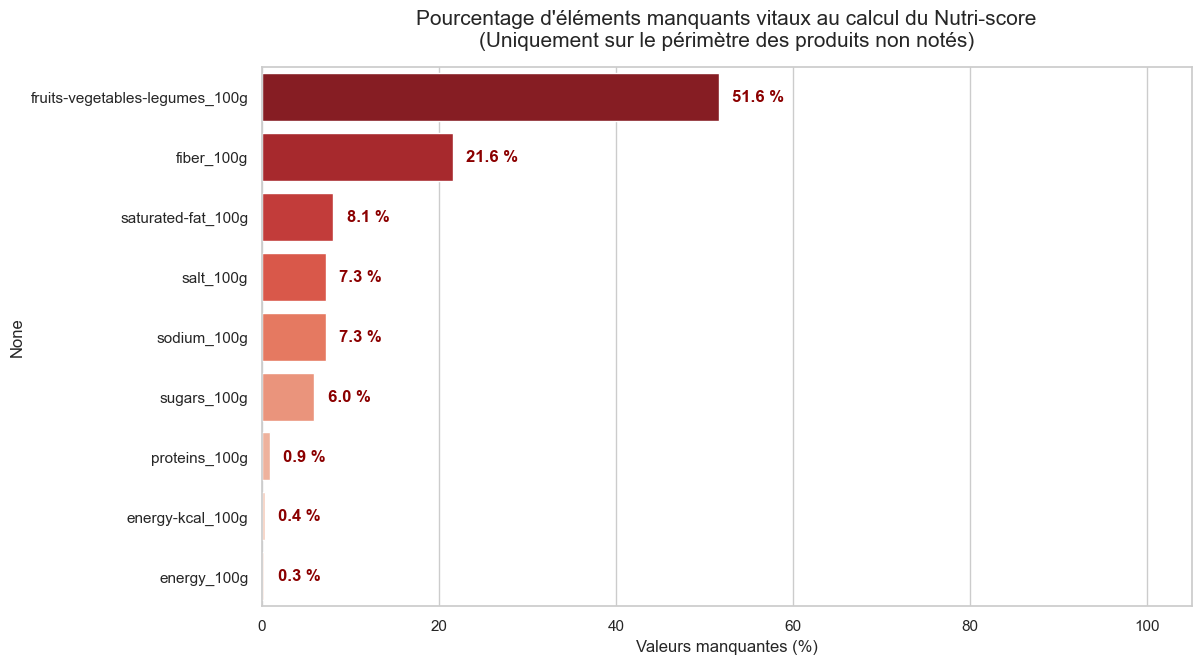

In [4]:
if 'df_calcul' in locals():
    # Calcul du % ( (nombre de NaN / nombre de lignes) * 100 )
    pourcentages_manquants = (df_calcul.isna().sum() / len(df_calcul)) * 100
    pourcentages_manquants = pourcentages_manquants.sort_values(ascending=False)

    plt.figure(figsize=(12, 7))
    barplot = sns.barplot(x=pourcentages_manquants.values, y=pourcentages_manquants.index, palette="Reds_r")

    plt.title("Pourcentage d'éléments manquants vitaux au calcul du Nutri-score\n(Uniquement sur le périmètre des produits non notés)", fontsize=15, pad=15)
    plt.xlabel("Valeurs manquantes (%)")
    plt.xlim(0, 105)

    # Annotation dynamique des pourcentages sur le graphique
    for index, value in enumerate(pourcentages_manquants):
        plt.text(value + 1.5, index, f"{value:.1f} %", va='center', fontweight='bold', color='darkred')

    plt.show()

## 4. Bilan de faisabilité (Combien pouvons-nous en sauver ?)

Un produit est estimé "Calculable sur le champ" si ***tous*** ses fondamentaux (énergie, graisses saturées, sucres, protéines, sel) sont remplis.
*(NB: L'absence d'information sur le % de Fruits/Légumes est souvent traitée comme un '0' dans l'algorithme)*

In [5]:
if 'df_calcul' in locals():
    # Construction de la liste des nutriments "bloquants" s'ils sont nuls
    socle_vital = []

    # L'un ou l'autre pour l'énergie et le sel
    if 'energy_100g' in colonnes_existantes:
        socle_vital.append('energy_100g')
    elif 'energy-kcal_100g' in colonnes_existantes:
        socle_vital.append('energy-kcal_100g')
        
    if 'salt_100g' in colonnes_existantes:
        socle_vital.append('salt_100g')
    elif 'sodium_100g' in colonnes_existantes:
        socle_vital.append('sodium_100g')

    for c in ['sugars_100g', 'saturated-fat_100g', 'proteins_100g']:
        if c in colonnes_existantes:
            socle_vital.append(c)

    # On compte combien de produits n'ont AUCUN composant manquant dans le socle vital
    produits_calculables = df_calcul.dropna(subset=socle_vital)

    nb_total = len(df_calcul)
    nb_sauvables = len(produits_calculables)

    print(f"Sur les {nb_total:,} produits dépourvus de Nutri-score :\n")
    print(f"✅ {nb_sauvables:,} produits ({(nb_sauvables/nb_total)*100:.1f} %) ont 100% des macro-nutriments renseignés.")
    print(f"   ➔ Vous pouvez calculer leur Nutri-score vous-même dans la boucle suivante !\n")
    print(f"❌ {nb_total - nb_sauvables:,} produits ({(1 - nb_sauvables/nb_total)*100:.1f} %) ont des trous de données majeurs.")
    print(f"   ➔ Imputation (Machine Learning) requise pour les deviner.")

    # Aperçu de ces miraculés qui n'attendent que notre calcul
    display(produits_calculables[socle_vital].head())

Sur les 65,161 produits dépourvus de Nutri-score :

✅ 55,346 produits (84.9 %) ont 100% des macro-nutriments renseignés.
   ➔ Vous pouvez calculer leur Nutri-score vous-même dans la boucle suivante !

❌ 9,815 produits (15.1 %) ont des trous de données majeurs.
   ➔ Imputation (Machine Learning) requise pour les deviner.


,energy_100g,salt_100g,sugars_100g,saturated-fat_100g,proteins_100g
0,584.0000,0.310000,0.270000,2.640000,13.000000
1,356.3625,0.525000,12.000000,0.000000,3.000000
2,56.5250,1.511628,27.906977,1.162791,9.302326
3,1536.0000,3.975000,2.000000,6.000000,8.000000
4,1530.0000,0.000000,1.000000,0.500000,5.000000


## 5. Matrice de Corrélation entre les Composants du Nutri-score

Voici la carte thermique (**heatmap**) des corrélations entre les nutriments qui entrent dans le calcul du Nutri-score.
Un coefficient proche de **+1** signifie que les deux indicateurs augmentent ensemble ;  
proche de **-1**, ils évoluent en sens inverse ;  
proche de **0**, ils sont indépendants.

In [ ]:
if 'df_calcul' in locals():
    # Noms courts pour l'affichage dans la heatmap
    noms_courts = {
        'energy_100g': 'Energie (kJ)',
        'energy-kcal_100g': 'Energie (kcal)',
        'sugars_100g': 'Sucres',
        'saturated-fat_100g': 'Graisses sat.',
        'salt_100g': 'Sel',
        'sodium_100g': 'Sodium',
        'fiber_100g': 'Fibres',
        'proteins_100g': 'Proteines',
        'fruits-vegetables-legumes_100g': 'Fruits/Leg.',
        'fruits-vegetables-nuts-estimate-from-ingredients_100g': 'Fruits (estim.)'
    }

    # Calcul de la matrice de correlation sur les lignes completement renseignees
    df_corr = df_calcul.dropna()
    matrice_corr = df_corr.corr(numeric_only=True)
    matrice_corr = matrice_corr.rename(index=noms_courts, columns=noms_courts)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        matrice_corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        square=True
    )
    plt.title("Matrice de correlation entre les composants du Nutri-score\n(Produits dont TOUS les nutriments sont renseignes)", fontsize=14, pad=15)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Exportation en CSV des produits sans Nutri-score

Nous sauvons ce tableau exclusivement rempli de produits orphelins (en conservant toutes leurs informations descriptives : noms, pays, ingrédients, etc.) afin d'avoir un terrain de jeu propre pour notre Machine Learning / Imputation.

In [6]:
if 'df_a_calculer' in locals():
    fichier_sortie = 'produits_sans_nutriscore.csv'
    
    # --- NETTOYAGE DES CODES-BARRES ---
    # On s'assure que les codes-barres retrouvent leur format texte pur sans le '.0'
    # causé par le typage Float de Pandas lors des trous de données.
    if 'code' in df_a_calculer.columns:
        df_a_calculer['code'] = df_a_calculer['code'].astype(str).str.replace(r'\.0$', '', regex=True)
        df_a_calculer['code'] = df_a_calculer['code'].replace('nan', '')
        
    # Exporter le dataframe DataFrame df_a_calculer (qui contient TOUTES les colonnes)
    # vers un nouveau fichier CSV sans conserver l'index pandas (index=False)
    df_a_calculer.to_csv(fichier_sortie, index=False, encoding='utf-8')
    
    print(f"💾 Super ! L'exportation est terminée.")
    print(f"   Le fichier '{fichier_sortie}' a bien été créé (avec les codes-barres formatés en texte brut).")
    print(f"   Il contient exactement et uniquement les {len(df_a_calculer):,} produits SANS Nutri-score.\n")
else:
    print("❌ Impossible d'exporter : Les données n'ont pas encore été chargées et filtrées.")
    print("   Veuillez exécuter la cellule '1. Isolement de la Cible' d'abord.")

💾 Super ! L'exportation est terminée.
   Le fichier 'produits_sans_nutriscore.csv' a bien été créé (avec les codes-barres formatés en texte brut).
   Il contient exactement et uniquement les 65,161 produits SANS Nutri-score.



## 7. Analyse inverse : Produits AVEC Nutri-score

Selon votre demande, regardons maintenant les produits qui **possèdent déjà un Nutri-score** dans OpenFoodFacts. L'objectif est de savoir quel est le pourcentage de ces produits dont nous aurions pu calculer le score nous-mêmes avec les données brutes (c'est-à-dire ceux qui ont 100% de leur macro-nutriments renseignés).

In [7]:
if 'df' in locals():
    # Isolation des produits AVEC un Nutri-score
    df_avec_nutriscore = df[df['nutriscore_score'].notna()].copy()
    nb_total_avec = len(df_avec_nutriscore)
    print(f"📦 Nombre de produits AVEC Nutri-score : {nb_total_avec:,}\n")
    
    # On restreint uniquement aux colonnes permettant le calcul
    df_calcul_avec = df_avec_nutriscore[colonnes_existantes]
    
    # On compte combien ont toutes les informations du socle vital (Energie, Sucre, Saturés, Sel, Protéines)
    produits_calculables_avec = df_calcul_avec.dropna(subset=socle_vital)
    nb_sauvables_avec = len(produits_calculables_avec)
    
    print(f"Sur les {nb_total_avec:,} produits possédant déjà un Nutri-score :\n")
    print(f"✅ {nb_sauvables_avec:,} produits ({(nb_sauvables_avec/nb_total_avec)*100:.1f} %) ont 100% des macro-nutriments renseignés pour recalculer le score.")
    print(f"❌ {nb_total_avec - nb_sauvables_avec:,} produits ({(1 - nb_sauvables_avec/nb_total_avec)*100:.1f} %) manquent de données brutes malgré leur Nutri-score final.")


📦 Nombre de produits AVEC Nutri-score : 0

Sur les 0 produits possédant déjà un Nutri-score :



ZeroDivisionError: division by zero